In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
import os

In [3]:
LONG_DATA_PATH = "./../data/raw/openaq_long_format.csv"
DATASET_PATH = "./../data/raw/openaq_ml_format.csv"

dfL = pd.read_csv(LONG_DATA_PATH)
df = pd.read_csv(DATASET_PATH)

In [34]:
dfL.shape

(12000, 6)

In [35]:
dfL.head(20)

,datetime_utc,datetime_local,sensor_id,parameter,unit,value
0,2026-01-01 00:00:00+00:00,2026-01-01 05:30:00+05:30,12234774,no,ppb,3.8000
1,2026-01-01 00:00:00+00:00,2026-01-01 05:30:00+05:30,12234779,relativehumidity,%,94.0000
2,2026-01-01 00:00:00+00:00,2026-01-01 05:30:00+05:30,12234780,so2,ppb,46.4000
3,2026-01-01 00:00:00+00:00,2026-01-01 05:30:00+05:30,12234778,pm25,µg/m³,127.0000
4,2026-01-01 00:00:00+00:00,2026-01-01 05:30:00+05:30,12234775,no2,ppb,55.5000
5,2026-01-01 00:00:00+00:00,2026-01-01 05:30:00+05:30,12234777,pm10,µg/m³,269.0000
6,2026-01-01 00:00:00+00:00,2026-01-01 05:30:00+05:30,14340710,nox,ppb,0.0325
7,2026-01-01 00:00:00+00:00,2026-01-01 05:30:00+05:30,12234781,temperature,c,12.2000
8,2026-01-01 00:00:00+00:00,2026-01-01 05:30:00+05:30,12234773,co,ppb,3.3900
9,2026-01-01 00:00:00+00:00,2026-01-01 05:30:00+05:30,14340712,wind_speed,m/s,1.1000


In [36]:
df.head()

,datetime_utc,co,no,no2,nox,o3,pm10,pm25,relativehumidity,so2,temperature,wind_direction,wind_speed
0,2026-01-01 00:00:00+00:00,3.39,3.8,55.5,0.0325,32.3,269.0,127.0,94.0,46.4,12.2,90.0,1.1
1,2026-01-01 00:15:00+00:00,3.38,3.7,53.4,0.0314,31.8,285.0,163.0,94.0,46.6,12.2,112.0,1.1
2,2026-01-01 00:30:00+00:00,3.29,3.2,50.6,0.0295,32.9,285.0,163.0,94.0,45.9,12.2,95.0,1.2
3,2026-01-01 00:45:00+00:00,3.18,4.1,48.1,0.0289,30.8,285.0,163.0,94.0,40.9,12.2,110.0,1.1
4,2026-01-01 01:00:00+00:00,3.16,3.6,48.9,0.0289,30.4,285.0,163.0,94.0,33.3,12.2,100.0,0.8


In [37]:
df.shape

(1086, 13)

In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1086 entries, 0 to 1085
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   datetime_utc      1086 non-null   str    
 1   co                1086 non-null   float64
 2   no                1086 non-null   float64
 3   no2               1086 non-null   float64
 4   nox               1086 non-null   float64
 5   o3                1086 non-null   float64
 6   pm10              1086 non-null   float64
 7   pm25              1086 non-null   float64
 8   relativehumidity  1086 non-null   float64
 9   so2               1086 non-null   float64
 10  temperature       1086 non-null   float64
 11  wind_direction    1086 non-null   float64
 12  wind_speed        1086 non-null   float64
dtypes: float64(12), str(1)
memory usage: 110.4 KB


In [39]:
df.head()

,datetime_utc,co,no,no2,nox,o3,pm10,pm25,relativehumidity,so2,temperature,wind_direction,wind_speed
0,2026-01-01 00:00:00+00:00,3.39,3.8,55.5,0.0325,32.3,269.0,127.0,94.0,46.4,12.2,90.0,1.1
1,2026-01-01 00:15:00+00:00,3.38,3.7,53.4,0.0314,31.8,285.0,163.0,94.0,46.6,12.2,112.0,1.1
2,2026-01-01 00:30:00+00:00,3.29,3.2,50.6,0.0295,32.9,285.0,163.0,94.0,45.9,12.2,95.0,1.2
3,2026-01-01 00:45:00+00:00,3.18,4.1,48.1,0.0289,30.8,285.0,163.0,94.0,40.9,12.2,110.0,1.1
4,2026-01-01 01:00:00+00:00,3.16,3.6,48.9,0.0289,30.4,285.0,163.0,94.0,33.3,12.2,100.0,0.8


## correlation check

In [4]:
df = df.drop(columns=["datetime_utc"])

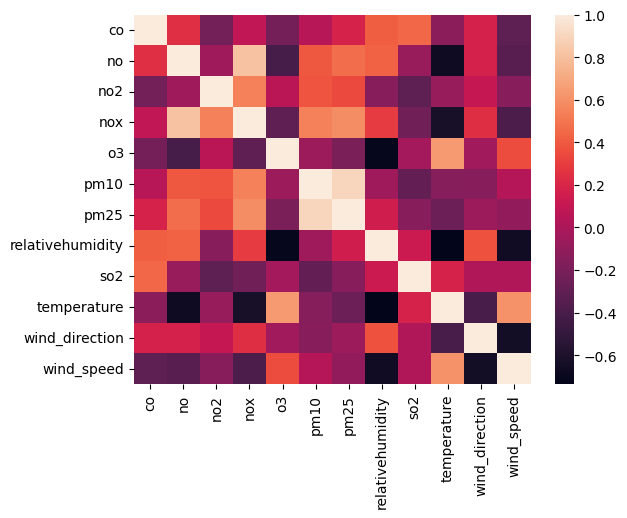

In [41]:
sns.heatmap(df.corr(), annot=False)
plt.savefig("../results/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

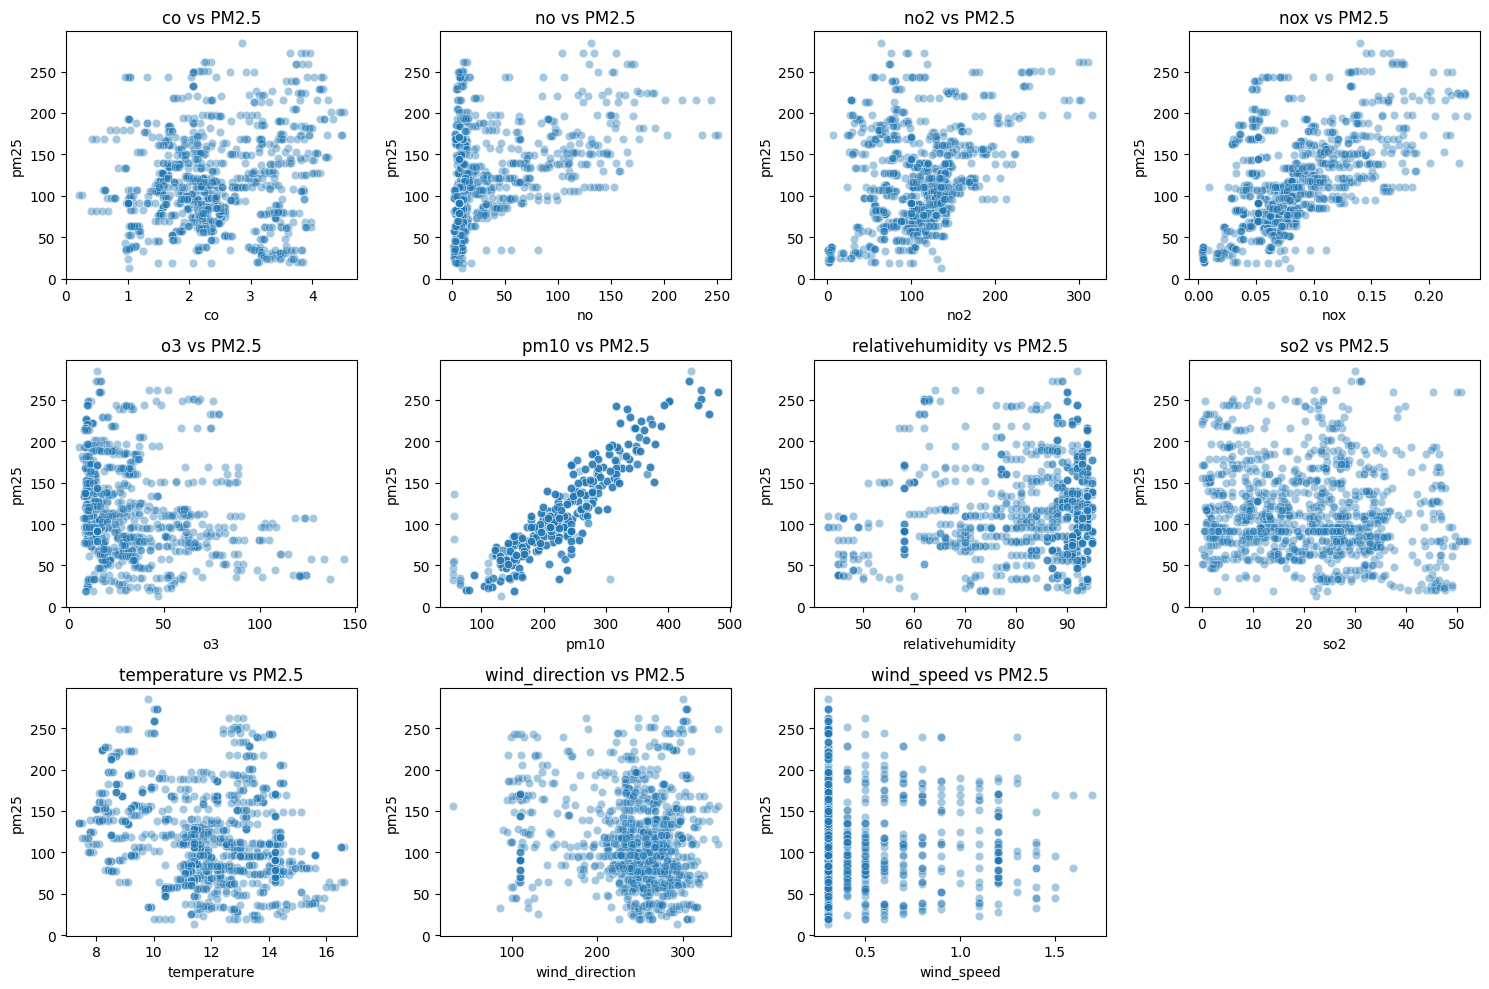

In [42]:
target = "pm25"
features = [col for col in df.columns if col != target]

plt.figure(figsize=(15, 10))

for i, col in enumerate(features):
    plt.subplot(3, 4, i+1)
    sns.scatterplot(data=df, x=col, y=target, alpha=0.4)
    plt.title(f"{col} vs PM2.5")

plt.tight_layout()
plt.show()

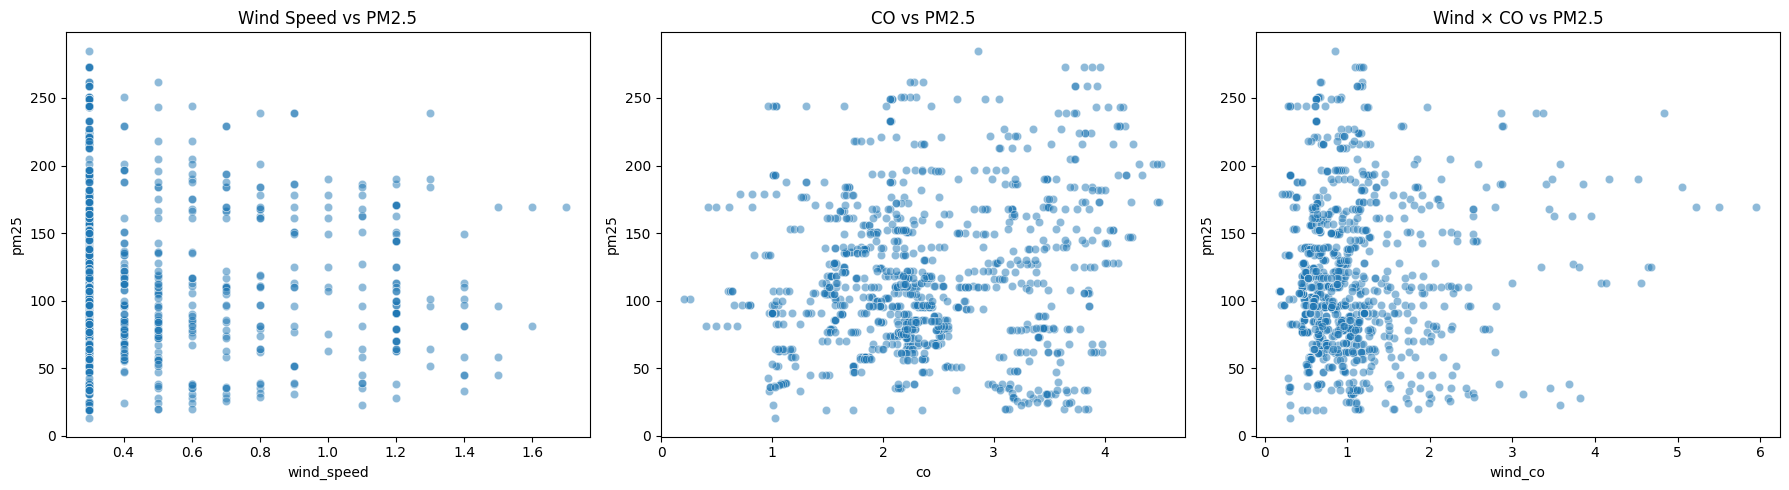

In [43]:
# Create interaction feature
df["wind_co"] = df["wind_speed"] * df["co"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. wind_speed vs PM2.5
sns.scatterplot(data=df, x="wind_speed", y="pm25", ax=axes[0], alpha=0.5)
axes[0].set_title("Wind Speed vs PM2.5")

# 2. CO vs PM2.5
sns.scatterplot(data=df, x="co", y="pm25", ax=axes[1], alpha=0.5)
axes[1].set_title("CO vs PM2.5")

# 3. interaction feature vs PM2.5
sns.scatterplot(data=df, x="wind_co", y="pm25", ax=axes[2], alpha=0.5)
axes[2].set_title("Wind × CO vs PM2.5")

plt.tight_layout()
plt.show()

In [44]:
corr_pm25 = df.corr(numeric_only=True)["pm25"].sort_values(ascending=False)
print(corr_pm25)

pm25                1.000000
pm10                0.898530
nox                 0.591678
no                  0.470708
no2                 0.338403
co                  0.184198
relativehumidity    0.156075
wind_co             0.060875
wind_direction     -0.058334
wind_speed         -0.102926
so2                -0.141841
o3                 -0.193716
temperature        -0.260938
Name: pm25, dtype: float64


In [7]:
df = df.drop(columns=["no", "o3", "so2","wind_direction", "wind_speed"])

In [8]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [9]:
df.head()

,co,no2,nox,pm10,pm25,relativehumidity,temperature
0,2.84,168.1,0.1449,276.0,149.0,87.0,8.5
1,4.13,85.4,0.0499,339.0,229.0,88.0,13.3
2,2.86,63.7,0.1407,437.0,285.0,92.0,9.8
3,0.21,69.6,0.0386,271.0,101.0,51.0,15.1
4,2.12,205.9,0.1507,268.0,122.0,87.0,11.0


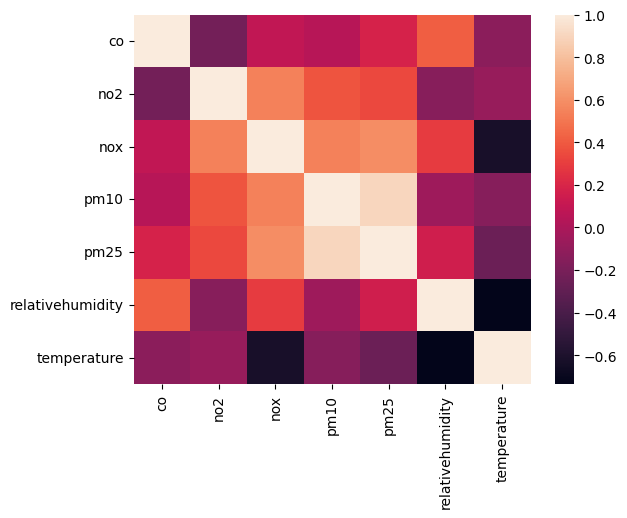

In [10]:
sns.heatmap(df.corr(), annot=False)
plt.savefig("../results/processed_corr_heatmap_.png", dpi=300, bbox_inches="tight")
plt.show()

In [49]:
output_path = "../data/processed"
os.makedirs(output_path, exist_ok=True)

# 3. Compute split sizes (75 / 15 / 15)
train_size = int(0.75 * len(df))
val_size = int(0.15 * len(df))

# 4. Split data
train_df = df[:train_size]
val_df = df[train_size:train_size + val_size]
test_df = df[train_size + val_size:]

train_df.to_csv(f"{output_path}/train.csv", index=False)
val_df.to_csv(f"{output_path}/val.csv", index=False)
test_df.to_csv(f"{output_path}/test.csv", index=False)

print("Datasets saved successfully in:", output_path)

Datasets saved successfully in: ../data/processed
